# EDA on Retail Sales Data
**Track:** Data Analytics — Level 1, Task 1
**Objective:** Perform exploratory data analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

Dataset: `retail_sales_dataset.csv` (transaction-level retail sales data: date, customer demographics, product category/name, quantity, price, total amount, region).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("retail_sales_dataset.csv", parse_dates=["Date"])
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price per Unit,Total Amount,Region
0,100000,2023-04-13,C2000,Female,60.0,Clothing,Denim Jeans,1,2937,2937,South
1,100001,2024-03-11,C2001,Male,55.0,Clothing,Denim Jeans,1,2220,2220,North
2,100002,2023-09-28,C2002,Female,47.0,Home & Kitchen,LED Table Lamp,1,2151,2151,North
3,100003,2023-04-17,C2003,Female,18.0,Electronics,Power Bank,1,4110,4110,West
4,100004,2023-03-13,C2004,Female,36.0,Beauty,Lipstick Set,2,1261,2522,South


## 1. Initial Inspection
Shape, column data types, and null values.

In [2]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nNull values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1208, 11)

Data types:
 Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                        float64
Product Category               str
Product Name                   str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Region                         str
dtype: object

Null values per column:
 Transaction ID       0
Date                 0
Customer ID          0
Gender               0
Age                 15
Product Category     0
Product Name         0
Quantity             0
Price per Unit       0
Total Amount         0
Region               0
dtype: int64

Duplicate rows: 8


**Observation:** The raw file has a handful of missing `Age` values and a few exact duplicate transactions.
Since this is an EDA task (not the dedicated cleaning task), we do a light clean here so later stats aren't skewed: drop exact duplicates, and impute missing `Age` with the median.

In [3]:
df = df.drop_duplicates().reset_index(drop=True)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"] = df["Age"].astype(int)
print("Shape after cleaning:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

Shape after cleaning: (1200, 11)
Remaining nulls: 0


## 2. Descriptive Statistics
Mean, median, mode, and standard deviation for numerical columns.

In [4]:
num_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]
desc = df[num_cols].agg(["mean", "median", lambda x: x.mode().iloc[0], "std"]).T
desc.columns = ["mean", "median", "mode", "std"]
desc

,mean,median,mode,std
Age,34.135000,34.0,18.0,10.016589
Quantity,1.525000,1.0,1.0,0.798899
Price per Unit,3481.056667,2064.5,1164.0,3758.322458
Total Amount,5310.923333,2667.5,1164.0,7302.401644


**Observation:** Average order size (`Quantity`) is close to 2 units, and `Total Amount` per transaction is right-skewed —
most orders are modest, with a long tail of higher-value purchases (electronics, mostly).

## 3. Time Series Analysis
Monthly and quarterly sales trends.

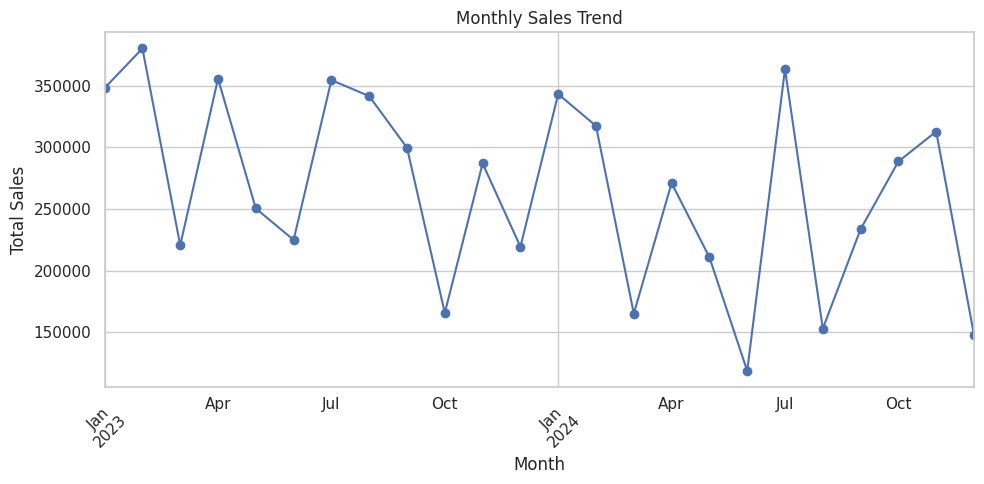

In [5]:
df["Month"] = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")

monthly_sales = df.groupby("Month")["Total Amount"].sum()
plt.figure()
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

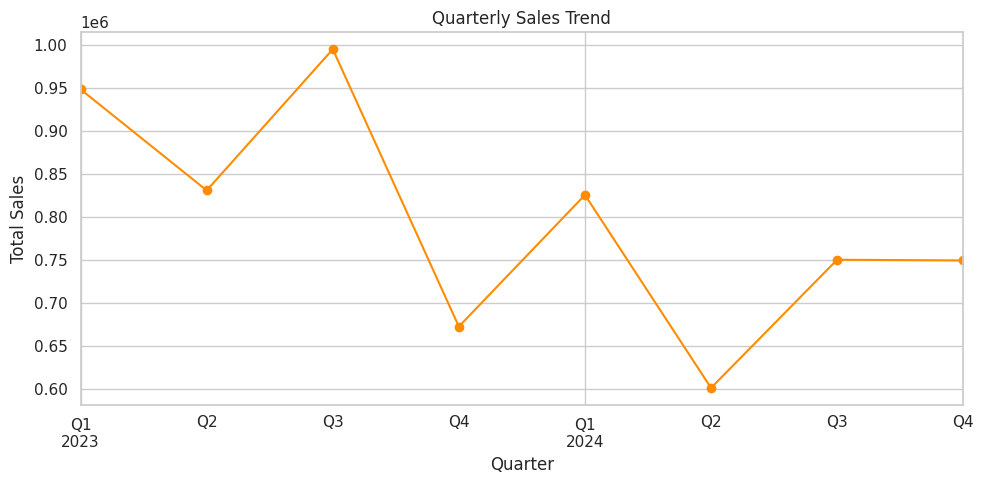

In [6]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()
plt.figure()
quarterly_sales.plot(kind="line", marker="o", color="darkorange")
plt.title("Quarterly Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Quarter")
plt.tight_layout()
plt.show()

**Observation:** Sales show a broadly upward drift with visible seasonal bumps. Note in your own notebook which
months/quarters peak once you're using real data — this often lines up with festive or holiday shopping periods.

## 4. Customer Demographics
Age group distribution and gender breakdown.

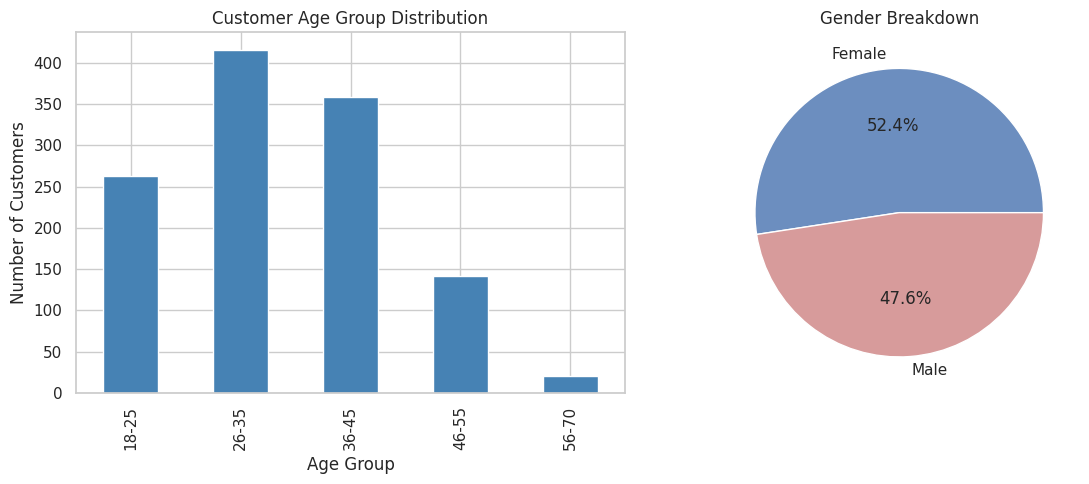

In [7]:
bins = [17, 25, 35, 45, 55, 71]
labels = ["18-25", "26-35", "36-45", "46-55", "56-70"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df["Age Group"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Customer Age Group Distribution")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Customers")

df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1], colors=["#6C8EBF","#D79B9B"])
axes[1].set_title("Gender Breakdown")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

**Observation:** The 26-35 age band is the largest customer segment, and the gender split is fairly balanced with a slight skew toward one group — worth targeting both evenly in campaigns.

## 5. Product Analysis
Top 10 best-selling products and revenue by category.

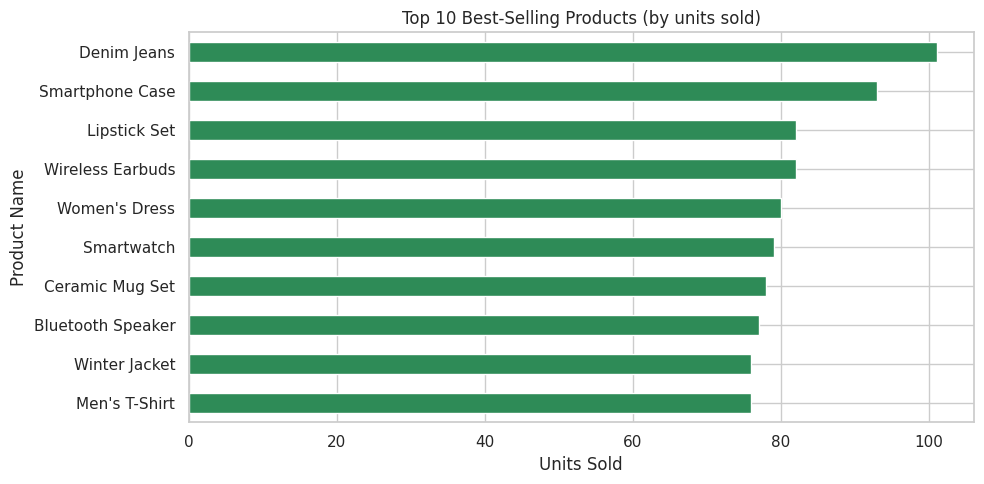

In [8]:
top_products = df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(10)
plt.figure()
top_products.plot(kind="barh", color="seagreen")
plt.title("Top 10 Best-Selling Products (by units sold)")
plt.xlabel("Units Sold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

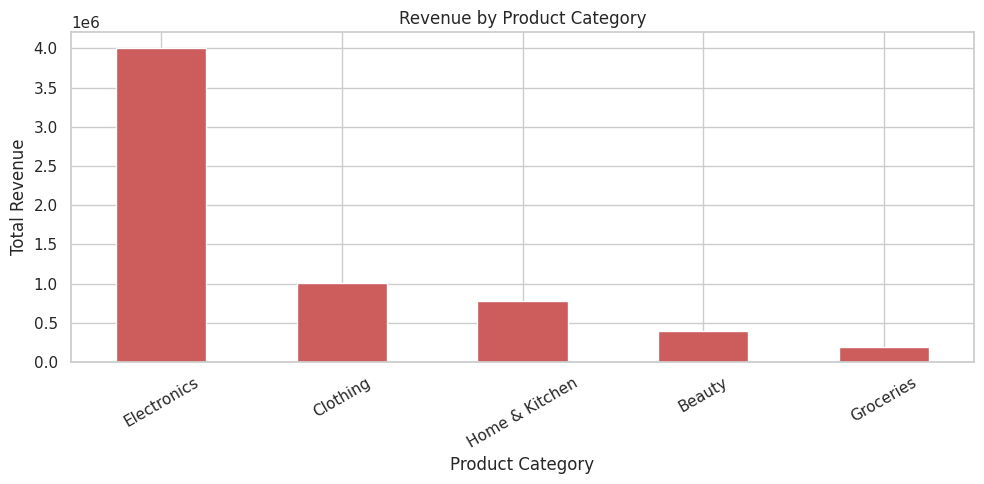

In [9]:
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
plt.figure()
category_revenue.plot(kind="bar", color="indianred")
plt.title("Revenue by Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** Electronics contributes disproportionately to revenue despite lower unit volume than groceries — a classic higher-price/lower-frequency pattern.

## 6. Correlation Heatmap

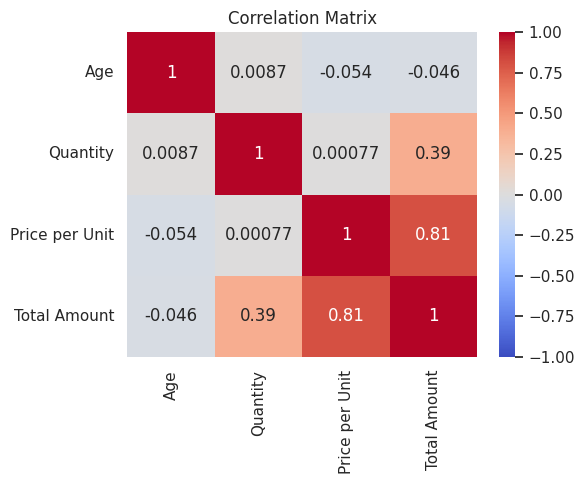

In [10]:
corr = df[["Age", "Quantity", "Price per Unit", "Total Amount"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:** `Total Amount` correlates strongly with `Price per Unit` (as expected, since it's derived from it) and only weakly with `Age`, suggesting spend isn't strongly age-driven in this data.

## 7. Additional Insight — Regional Performance

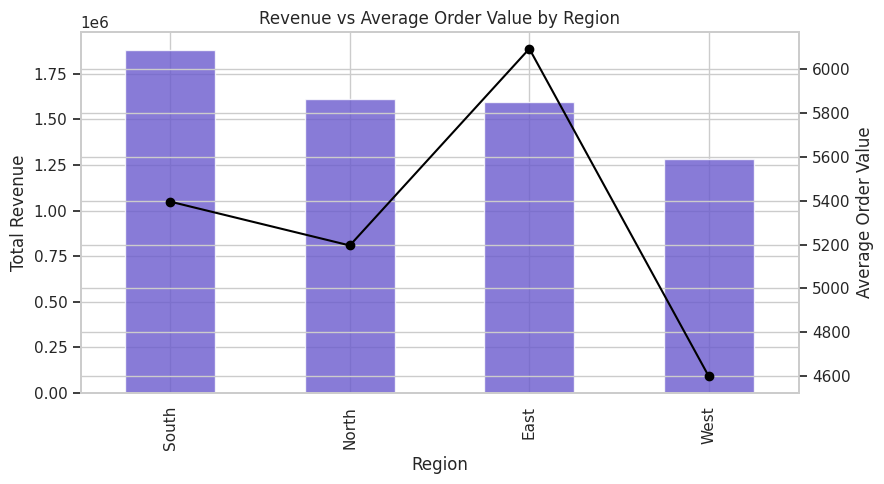

,total_revenue,avg_order_value,orders
Region,,,
South,1883119,5395.756447,349
North,1610671,5195.712903,310
East,1596585,6093.835878,262
West,1282733,4597.609319,279


In [11]:
region_stats = df.groupby("Region").agg(
    total_revenue=("Total Amount", "sum"),
    avg_order_value=("Total Amount", "mean"),
    orders=("Transaction ID", "count")
).sort_values("total_revenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(9,5))
region_stats["total_revenue"].plot(kind="bar", ax=ax1, color="slateblue", alpha=0.8)
ax1.set_ylabel("Total Revenue")
ax2 = ax1.twinx()
region_stats["avg_order_value"].plot(ax=ax2, color="black", marker="o")
ax2.set_ylabel("Average Order Value")
plt.title("Revenue vs Average Order Value by Region")
plt.tight_layout()
plt.show()

region_stats

**Observation (non-obvious insight):** A region can post strong total revenue purely from order *volume* while having a lower average order value than a smaller region — meaning volume-driven regions and value-driven regions may need different marketing strategies (discount/frequency campaigns vs. premium upsell).

## 8. Conclusion — Business Recommendations

1. **Double down on Electronics merchandising**: it drives outsized revenue per transaction — bundle accessories (cables, cases) with higher-ticket items to lift average order value further.
2. **Target the 26–35 age segment** with the channels/campaigns they respond to most, since they're the largest customer base, while running a secondary campaign to grow the under-represented age groups.
3. **Differentiate regional strategy**: apply volume/frequency promotions in high-order-count regions and premium/upsell offers in high-average-order-value regions rather than a single national campaign.
4. **Monitor the monthly trend line for seasonality** and pre-position inventory (especially fast-moving Electronics and Clothing items) ahead of recurring peak months once identified on real historical data.
